# Transformer Encoder 감성 분류기

**수행 실험 목록**
- 실험 1 : 베이스라인 모델 구현
- 실험 2 : Encoder Layer 수 비교 (1, 2, 4, 6)
- 실험 4 : Positional Encoding 제거 실험
- 실험 6 : Residual Connection 제거 실험
- 실험 8 : FFN 크기 변경 (128, 256, 512, 1024)
- Single Head : Single Head Transformer + Attention Map 시각화


## 0. 환경 설치

In [1]:
!pip install datasets -q

## 1. 라이브러리 & 디바이스 설정

In [2]:
import torch
print(torch.cuda.is_available())       # True여야 함
print(torch.cuda.device_count())       # GPU 개수
print(torch.cuda.get_device_name(0))   # GPU 이름


True
4
NVIDIA TITAN Xp


In [3]:
import math
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib
# 서버에 설치된 한글 폰트 사용
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

/home/undergraduate/20231372_TY/envs/transformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0
GPU: NVIDIA TITAN Xp
메모리: 11.9 GB


## 2. 하이퍼파라미터 설정
베이스라인 기준 CONFIG. 각 실험에서 해당 값만 덮어써서 사용

In [4]:
CONFIG = {
    "vocab_size"  : 10000,
    "d_embed"     : 128,      # embedding 차원 (d_model)
    "max_len"     : 256,
    "n_layer"     : 2,        # Encoder Block 개수 (실험 2에서 변경)
    "n_head"      : 4,        # Attention head 수
    "d_ff"        : 256,      # FFN hidden size (실험 8에서 변경)
    "dropout"     : 0.1,
    "n_class"     : 2,        # positive / negative
    "batch_size"  : 64,
    "epochs"      : 5,
    "lr"          : 1e-3,
    "use_pe"      : True,     # Positional Encoding 여부 (실험 4에서 변경)
    "use_residual": True,     # Residual Connection 여부 (실험 6에서 변경)
    "single_head_mode": False,
}

## 3. 데이터셋 & 토크나이저
**IMDb 영화 리뷰 데이터셋** (positive / negative)
- 강의자료 흐름: Input Sentence → Token → one-hot → Embedding
- `<CLS>` 토큰을 문장 맨 앞에 추가 → Encoder 통과 후 CLS Vector로 분류
- PAD 토큰(0)으로 길이를 맞춤 → Pad Masking 적용

In [5]:
class SimpleTokenizer:
    """단어를 정수 ID로 변환하는 간단한 토크나이저"""
    def __init__(self, vocab_size=10000):
        self.vocab_size = vocab_size
        # 특수 토큰: PAD=0, UNK=1, CLS=2
        self.word2idx = {"<PAD>": 0, "<UNK>": 1, "<CLS>": 2}
        self.idx2word = {0: "<PAD>", 1: "<UNK>", 2: "<CLS>"}

    def build_vocab(self, texts):
        from collections import Counter
        counter = Counter()
        for text in texts:
            counter.update(text.lower().split())
        for word, _ in counter.most_common(self.vocab_size - 3):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word
        print(f"Vocab size: {len(self.word2idx)}")

    def encode(self, text, max_len=256):
        # [CLS] 토큰을 맨 앞에 추가 (분류용 벡터)
        tokens = ["<CLS>"] + text.lower().split()
        ids = [self.word2idx.get(t, 1) for t in tokens]  # 없으면 UNK=1
        # padding / truncation
        if len(ids) < max_len:
            ids = ids + [0] * (max_len - len(ids))   # PAD로 채우기
        else:
            ids = ids[:max_len]
        return ids


class IMDbDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.data = [
            (torch.tensor(tokenizer.encode(t, max_len), dtype=torch.long),
             torch.tensor(l, dtype=torch.long))
            for t, l in zip(texts, labels)
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def load_imdb(vocab_size=10000, max_len=256, max_train=5000, max_test=1000):
    print("Loading IMDb dataset (sklearn)...")
    from sklearn.datasets import load_files
    # sklearn에 내장된 IMDb 대신 직접 다운로드
    import urllib.request, tarfile, os

    # 다운로드 경로
    data_dir = "/home/undergraduate/20231372_TY/imdb_data"
    tar_path = data_dir + "/aclImdb_v1.tar.gz"

    if not os.path.exists(data_dir + "/aclImdb"):
        os.makedirs(data_dir, exist_ok=True)
        print("Downloading IMDb...")
        urllib.request.urlretrieve(
            "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
            tar_path
        )
        with tarfile.open(tar_path) as tar:
            tar.extractall(data_dir)
        print("Download complete!")

    def read_data(split, max_count):
        texts, labels = [], []
        for label, folder in [(1, "pos"), (0, "neg")]:
            path = f"{data_dir}/aclImdb/{split}/{folder}"
            files = os.listdir(path)[:max_count // 2]
            for fname in files:
                with open(f"{path}/{fname}", encoding="utf-8") as f:
                    texts.append(f.read())
                labels.append(label)
        return texts, labels

    train_texts, train_labels = read_data("train", max_train)
    test_texts,  test_labels  = read_data("test",  max_test)

    tokenizer = SimpleTokenizer(vocab_size)
    tokenizer.build_vocab(train_texts)

    train_ds = IMDbDataset(train_texts, train_labels, tokenizer, max_len)
    test_ds  = IMDbDataset(test_texts,  test_labels,  tokenizer, max_len)
    return train_ds, test_ds, tokenizer

# 데이터 로드
train_dataset, test_dataset, tokenizer = load_imdb(
    vocab_size=CONFIG["vocab_size"],
    max_len=CONFIG["max_len"],
    max_train=5000,
    max_test=1000
)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"])
print(f"Train: {len(train_dataset)}개 / Test: {len(test_dataset)}개")

Loading IMDb dataset (sklearn)...
Vocab size: 10000
Train: 5000개 / Test: 1000개


## 4. Embedding 구현

```
TransformerEmbedding = TokenEmbedding + PositionalEncoding
```

**TokenEmbedding**: 정수 토큰 → d_embed 차원 벡터 (학습 가능한 lookup table)  
**PositionalEncoding**: sin/cos 함수로 위치 정보 주입 (학습 대상 아님, 고정값)  

$$PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \quad PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

In [6]:
class TokenEmbedding(nn.Module):

    def __init__(self, vocab_size, d_embed):
        super(TokenEmbedding, self).__init__()
        # 단어 ID를 d_embed 차원의 의미 벡터로 바꿔주는 학습 가능한 lookup table
        self.embedding = nn.Embedding(vocab_size, d_embed, padding_idx=0)
        self.d_embed   = d_embed

    def forward(self, x):
        out = self.embedding(x) * math.sqrt(self.d_embed)
        return out


class PositionalEncoding(nn.Module):

    def __init__(self, d_embed, max_len=256, device=torch.device("cpu")):
        super(PositionalEncoding, self).__init__()

        encoding = torch.zeros(max_len, d_embed)    # (max_len, d_embed) 크기 행렬
        encoding.requires_grad = False              # 학습 대상 아님 -> 고정값

        # position shape: (max_len, 1)
        position = torch.arange(0, max_len).float().unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_embed, 2) * -(math.log(10000.0) / d_embed)
        )

        encoding[:, 0::2] = torch.sin(position * div_term)  # 짝수 index -> sin
        encoding[:, 1::2] = torch.cos(position * div_term)  # 홀수 index -> cos

        # (max_len, d_embed) -> (1, max_len, d_embed): batch 차원 추가 (WHY? 입력 x가 3차원)
        self.encoding = encoding.unsqueeze(0).to(device)

    def forward(self, x):
        _, seq_len, _ = x.size()                    # 입력 데이터 x의 단어 개수
        pos_embed = self.encoding[:, :seq_len, :]   # 필요한 길이만 사용
        out = x + pos_embed                         # x shape과 encoding shape 맞춰서 합산
        return out


class TransformerEmbedding(nn.Module):

    def __init__(self, vocab_size, d_embed, max_len, device, use_pe=True):
        super(TransformerEmbedding, self).__init__()
        self.token_embed = TokenEmbedding(vocab_size, d_embed)
        self.pos_embed   = PositionalEncoding(d_embed, max_len, device)
        self.use_pe      = use_pe
        self.dropout     = nn.Dropout(0.1)

    def forward(self, x):
        tok = self.token_embed(x)
        if self.use_pe:
            tok = self.pos_embed(tok)
        return self.dropout(tok)

print("Embedding 클래스 정의 완료")

Embedding 클래스 정의 완료


## 5. Attention 구현

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q × K^T** → 유사도(Attention Score) 계산
- **/ √d_k** → 학습 안정화 (Scale)
- **Mask** → PAD 토큰 제거 (-1e9 채워서 softmax 후 0이 되게)
- **Softmax** → 확률화 (Attention Probability)
- **× V** → 중요한 정보만 골라서 합침

In [7]:
def calculate_attention(query, key, value, mask=None):

    d_k = key.shape[-1]

    # Q x K^T -> (n_batch, seq_len, seq_len)
    attention_score = torch.matmul(query, key.transpose(-2, -1))
    attention_score = attention_score / math.sqrt(d_k)

    if mask is not None:
        attention_score = attention_score.masked_fill(mask == 0, -1e9)

    attention_prob = F.softmax(attention_score, dim=-1)   # (n_batch, seq_len, seq_len)
    out = torch.matmul(attention_prob, value)              # (n_batch, seq_len, d_k)
    return out, attention_prob


class MultiHeadAttention(nn.Module):

    def __init__(self, d_embed, n_head):
        super(MultiHeadAttention, self).__init__()
        assert d_embed % n_head == 0, "d_embed must be divisible by n_head"
        self.n_head = n_head
        self.d_k    = d_embed // n_head

        # 강의자료: W^Q, W^K, W^V (FC layer)
        self.W_Q = nn.Linear(d_embed, d_embed)
        self.W_K = nn.Linear(d_embed, d_embed)
        self.W_V = nn.Linear(d_embed, d_embed)
        self.W_O = nn.Linear(d_embed, d_embed)  # 출력 projection

    def forward(self, x, mask=None):
        batch = x.size(0)

        # (batch, seq_len, d_embed) -> (batch, n_head, seq_len, d_k)
        Q = self.W_Q(x).view(batch, -1, self.n_head, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch, -1, self.n_head, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch, -1, self.n_head, self.d_k).transpose(1, 2)

        if mask is not None:
            mask = mask.unsqueeze(1)  # (batch, 1, seq_len, seq_len)

        out, attn_prob = calculate_attention(Q, K, V, mask)

        # head 합치기: (batch, n_head, seq_len, d_k) -> (batch, seq_len, d_embed)
        out = out.transpose(1, 2).contiguous().view(batch, -1, self.n_head * self.d_k)
        out = self.W_O(out)
        return out, attn_prob


class SingleHeadAttention(nn.Module):

    def __init__(self, d_embed):
        super(SingleHeadAttention, self).__init__()
        self.W_Q = nn.Linear(d_embed, d_embed)
        self.W_K = nn.Linear(d_embed, d_embed)
        self.W_V = nn.Linear(d_embed, d_embed)
        self.W_O = nn.Linear(d_embed, d_embed)

    def forward(self, x, mask=None):
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        out, attn_prob = calculate_attention(Q, K, V, mask)
        out = self.W_O(out)
        return out, attn_prob

print("Attention 클래스 정의 완료")

Attention 클래스 정의 완료


## 6. Encoder Block 구현

**Encoder Block 구성:**
1. Multi-Head Attention Layer
2. Position-wise Feed-Forward Layer

각 서브레이어에 **Add & Norm** (Residual Connection + LayerNorm) 적용  
`use_residual=False`로 설정 시 Residual 제거 → **실험 6**

In [8]:
class PositionWiseFeedForward(nn.Module):

    def __init__(self, d_embed, d_ff, dropout=0.1):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1     = nn.Linear(d_embed, d_ff)
        self.fc2     = nn.Linear(d_ff, d_embed)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(F.relu(self.fc1(x))))


class EncoderBlock(nn.Module):

    def __init__(self, self_attention, position_ff, d_embed, use_residual=True, dropout=0.1):
        super(EncoderBlock, self).__init__()
        self.self_attention = self_attention
        self.position_ff    = position_ff
        self.use_residual   = use_residual
        self.norm1   = nn.LayerNorm(d_embed)
        self.norm2   = nn.LayerNorm(d_embed)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # (1) Self-Attention + Add & Norm
        attn_out, attn_prob = self.self_attention(x, mask)
        if self.use_residual:
            x = self.norm1(x + self.dropout(attn_out))    # Residual 있음
        else:
            x = self.norm1(self.dropout(attn_out))         # Residual 없음 (실험 6)

        # (2) Feed-Forward + Add & Norm
        ff_out = self.position_ff(x)
        if self.use_residual:
            x = self.norm2(x + self.dropout(ff_out))      # Residual 있음
        else:
            x = self.norm2(self.dropout(ff_out))           # Residual 없음 (실험 6)

        return x, attn_prob

print("EncoderBlock 정의 완료")

EncoderBlock 정의 완료


## 7. Encoder 구현

```python
class Encoder(nn.Module):
    def __init__(self, encoder_block, n_layer):
        for i in range(n_layer):
            self.layers.append(copy.deepcopy(encoder_block))  # 독립적인 복사
    def forward(self, x):
        for layer in self.layers:
            out = layer(out)
        return out
```
`n_layer` 변경으로 **실험 2** 수행

In [9]:
class Encoder(nn.Module):

    def __init__(self, encoder_block, n_layer):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList(
            [copy.deepcopy(encoder_block) for _ in range(n_layer)]
        )

    def forward(self, x, mask=None):
        attn_weights = []
        out = x
        for layer in self.layers:
            out, attn = layer(out, mask)
            attn_weights.append(attn)   # 각 layer의 attention (시각화용)
        return out, attn_weights

print("Encoder 정의 완료")

Encoder 정의 완료


## 8. 전체 모델: SentimentClassifier

```
Input Sentence
      ↓
Token Embedding
      ↓
Positional Encoding
      ↓
Transformer Encoder
      ↓
CLS Vector  ← 첫 번째 토큰([CLS]) 추출
      ↓
Linear Layer
      ↓
Softmax
      ↓
Positive / Negative
```

In [10]:
class SentimentClassifier(nn.Module):

    def __init__(self, cfg):
        super(SentimentClassifier, self).__init__()

        d_embed = cfg["d_embed"]
        n_head  = cfg["n_head"]

        # (1) Embedding (Token + Positional)
        self.embedding = TransformerEmbedding(
            vocab_size=cfg["vocab_size"],
            d_embed=d_embed,
            max_len=cfg["max_len"],
            device=device,
            use_pe=cfg["use_pe"]         # 실험 4: False로 PE 제거
        )

        # (2) Attention 선택: Single Head or Multi Head
        if cfg.get("single_head_mode", False):
            attention = SingleHeadAttention(d_embed)
        else:
            attention = MultiHeadAttention(d_embed, n_head)

        # (3) Encoder Block 구성
        ffn = PositionWiseFeedForward(d_embed, cfg["d_ff"], cfg["dropout"])
        encoder_block = EncoderBlock(
            self_attention=attention,
            position_ff=ffn,
            d_embed=d_embed,
            use_residual=cfg["use_residual"],  # 실험 6: False로 Residual 제거
            dropout=cfg["dropout"]
        )

        # (4) Encoder (n_layer개의 block 쌓기)
        self.encoder = Encoder(encoder_block, cfg["n_layer"])

        # (5) Classification Head: [CLS] vector -> Linear -> 2 classes
        self.classifier = nn.Linear(d_embed, cfg["n_class"])
        self.dropout    = nn.Dropout(cfg["dropout"])

    def make_pad_mask(self, x):

        pad_mask = (x != 0).unsqueeze(1).unsqueeze(2)
        pad_mask = pad_mask.expand(-1, 1, x.size(1), x.size(1))
        return pad_mask.squeeze(1)

    def forward(self, x):
        mask = self.make_pad_mask(x)

        out = self.embedding(x)                   # (batch, seq_len, d_embed)
        out, attn_weights = self.encoder(out, mask)  # (batch, seq_len, d_embed)

        # [CLS] Vector: 첫 번째 토큰 추출
        cls_vector = out[:, 0, :]                 # (batch, d_embed)

        # Classification Head
        logits = self.classifier(self.dropout(cls_vector))  # (batch, 2)
        return logits, attn_weights

print("SentimentClassifier 정의 완료")

SentimentClassifier 정의 완료


## 9. 학습 & 평가 유틸리티 함수

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits, _ = model(ids)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        logits, _ = model(ids)
        loss = criterion(logits, labels)
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def run_experiment(cfg, train_loader, test_loader, exp_name=""):
    """실험 실행: 모델 생성 -> 학습 -> 평가"""
    print(f"\n{'='*60}")
    print(f"[실험] {exp_name}")
    print(f"  n_layer={cfg['n_layer']}, n_head={cfg['n_head']}, "
          f"d_ff={cfg['d_ff']}, use_pe={cfg['use_pe']}, use_residual={cfg['use_residual']}")
    print(f"{'='*60}")

    model     = SentimentClassifier(cfg).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    criterion = nn.CrossEntropyLoss()

    results = []
    for epoch in range(cfg["epochs"]):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        results.append({
            "epoch": epoch+1,
            "tr_loss": tr_loss, "tr_acc": tr_acc,
            "te_loss": te_loss, "te_acc": te_acc
        })
        print(f"  Epoch {epoch+1}/{cfg['epochs']} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
              f"Test  Loss: {te_loss:.4f} Acc: {te_acc:.4f}")

    print(f"  => 최종 Test Accuracy: {results[-1]['te_acc']:.4f}")
    return model, results, results[-1]["te_acc"]


def plot_results(results_dict, title="Experiment Results", save_path=None):
    """여러 실험 결과를 Test Accuracy / Test Loss 그래프로 비교"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for exp_name, results in results_dict.items():
        epochs    = [r["epoch"]   for r in results]
        te_accs   = [r["te_acc"]  for r in results]
        te_losses = [r["te_loss"] for r in results]
        axes[0].plot(epochs, te_accs,   marker="o", label=exp_name)
        axes[1].plot(epochs, te_losses, marker="o", label=exp_name)
    for ax, ylabel in zip(axes, ["Accuracy", "Loss"]):
        ax.set_title(f"{title} - Test {ylabel}")
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()

print("유틸리티 함수 정의 완료")

유틸리티 함수 정의 완료


## 10. 실험 1 — 베이스라인 모델
기본 설정으로 모델을 학습해 기준 성능(Test Accuracy)을 측정

| 설정 | 값 |
|------|-----|
| n_layer | 2 |
| n_head  | 4 |
| d_ff    | 256 |
| PE      | O |
| Residual| O |


[실험] 실험1 - 베이스라인
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6911 Acc: 0.5578 | Test  Loss: 0.6324 Acc: 0.6410
  Epoch 2/5 | Train Loss: 0.6089 Acc: 0.6614 | Test  Loss: 0.5568 Acc: 0.6970
  Epoch 3/5 | Train Loss: 0.5293 Acc: 0.7314 | Test  Loss: 0.5795 Acc: 0.6940
  Epoch 4/5 | Train Loss: 0.5080 Acc: 0.7464 | Test  Loss: 0.5011 Acc: 0.7600
  Epoch 5/5 | Train Loss: 0.4665 Acc: 0.7756 | Test  Loss: 0.4960 Acc: 0.7670
  => 최종 Test Accuracy: 0.7670


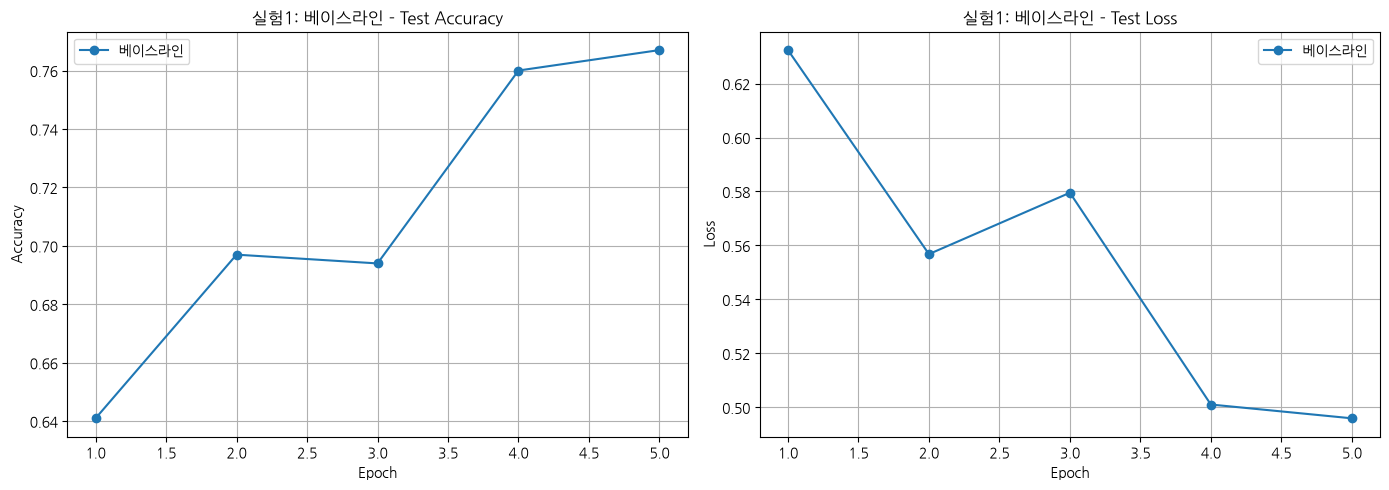


[실험 1] 최종 Test Accuracy: 0.7670


In [12]:
cfg_baseline = {**CONFIG, "n_layer": 2, "n_head": 4, "d_ff": 256,
                "use_pe": True, "use_residual": True}

model_baseline, res_baseline, acc_baseline = run_experiment(
    cfg_baseline, train_loader, test_loader, "실험1 - 베이스라인"
)

# 학습 곡선
plot_results({"베이스라인": res_baseline}, title="실험1: 베이스라인")
print(f"\n[실험 1] 최종 Test Accuracy: {acc_baseline:.4f}")

## 11. 실험 2 — Encoder Layer 수 비교
`n_layer`를 1, 2, 4, 6으로 변경하며 성능 변화를 측정

**분석 포인트**: Layer가 깊어질수록 성능이 향상되는가? 어느 시점부터 과적합이 발생하는가?


[실험] 실험2 - Encoder Layer 수: 1
  n_layer=1, n_head=4, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.7074 Acc: 0.5148 | Test  Loss: 0.7282 Acc: 0.5000
  Epoch 2/5 | Train Loss: 0.6913 Acc: 0.5360 | Test  Loss: 0.6889 Acc: 0.5480
  Epoch 3/5 | Train Loss: 0.6649 Acc: 0.5912 | Test  Loss: 0.6524 Acc: 0.6250
  Epoch 4/5 | Train Loss: 0.6503 Acc: 0.6132 | Test  Loss: 0.6435 Acc: 0.6300
  Epoch 5/5 | Train Loss: 0.6399 Acc: 0.6316 | Test  Loss: 0.6690 Acc: 0.6150
  => 최종 Test Accuracy: 0.6150

[실험] 실험2 - Encoder Layer 수: 2
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6826 Acc: 0.5628 | Test  Loss: 0.7417 Acc: 0.6040
  Epoch 2/5 | Train Loss: 0.6010 Acc: 0.6670 | Test  Loss: 0.5177 Acc: 0.7420
  Epoch 3/5 | Train Loss: 0.5152 Acc: 0.7404 | Test  Loss: 0.4783 Acc: 0.7710
  Epoch 4/5 | Train Loss: 0.4846 Acc: 0.7684 | Test  Loss: 0.4745 Acc: 0.7600
  Epoch 5/5 | Train Loss: 0.4463 Acc: 0.8004 | Test  Loss: 0.4962 Acc: 0.7540


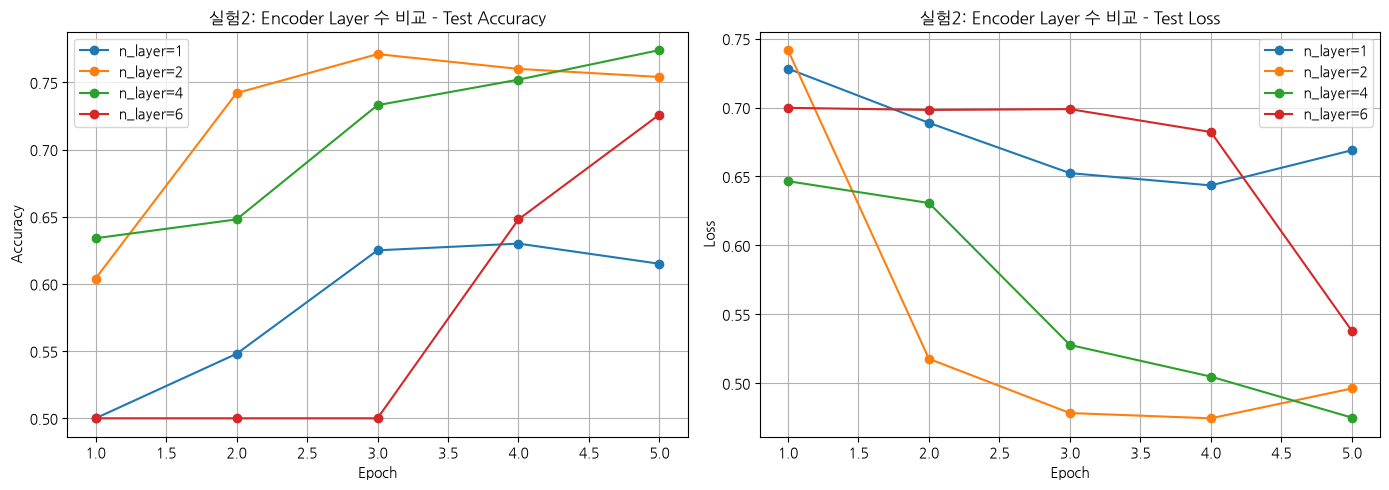


[실험 2 결과 요약]
설정                Test Accuracy
--------------------------------
n_layer=1                0.6150
n_layer=2                0.7540
n_layer=4                0.7740
n_layer=6                0.7260


In [13]:
results_exp2 = {}
acc_exp2     = {}

for n_layer in [1, 2, 4, 6]:
    cfg = {**CONFIG, "n_layer": n_layer, "use_pe": True, "use_residual": True}
    _, res, acc = run_experiment(
        cfg, train_loader, test_loader, f"실험2 - Encoder Layer 수: {n_layer}"
    )
    results_exp2[f"n_layer={n_layer}"] = res
    acc_exp2[f"n_layer={n_layer}"]     = acc

plot_results(results_exp2, title="실험2: Encoder Layer 수 비교")

print("\n[실험 2 결과 요약]")
print(f"{'설정':<15} {'Test Accuracy':>15}")
print("-" * 32)
for k, v in acc_exp2.items():
    print(f"{k:<15} {v:>15.4f}")

## 12. 실험 4 — Positional Encoding 제거 실험
`use_pe=False`로 PE를 제거한 모델과 베이스라인을 비교

**분석 포인트**: Transformer는 병렬 처리를 하기 때문에 순서 정보가 없다.  
PE를 제거하면 모델은 단어 순서를 알 수 없게 된다. 이때 성능은 어떻게 변할까?


[실험] 실험4 - PE 있음 (Before)
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6952 Acc: 0.5668 | Test  Loss: 0.5932 Acc: 0.6900
  Epoch 2/5 | Train Loss: 0.6212 Acc: 0.6462 | Test  Loss: 0.5364 Acc: 0.7290
  Epoch 3/5 | Train Loss: 0.5624 Acc: 0.7008 | Test  Loss: 0.5347 Acc: 0.7200
  Epoch 4/5 | Train Loss: 0.5102 Acc: 0.7524 | Test  Loss: 0.4947 Acc: 0.7620
  Epoch 5/5 | Train Loss: 0.4660 Acc: 0.7750 | Test  Loss: 0.5810 Acc: 0.6850
  => 최종 Test Accuracy: 0.6850

[실험] 실험4 - PE 없음 (After)
  n_layer=2, n_head=4, d_ff=256, use_pe=False, use_residual=True
  Epoch 1/5 | Train Loss: 0.6843 Acc: 0.5704 | Test  Loss: 0.6159 Acc: 0.6550
  Epoch 2/5 | Train Loss: 0.6103 Acc: 0.6654 | Test  Loss: 0.6145 Acc: 0.6750
  Epoch 3/5 | Train Loss: 0.5469 Acc: 0.7200 | Test  Loss: 0.5074 Acc: 0.7500
  Epoch 4/5 | Train Loss: 0.5047 Acc: 0.7538 | Test  Loss: 0.4800 Acc: 0.7700
  Epoch 5/5 | Train Loss: 0.4515 Acc: 0.7896 | Test  Loss: 0.4768 Acc: 0.7820
  => 최종 

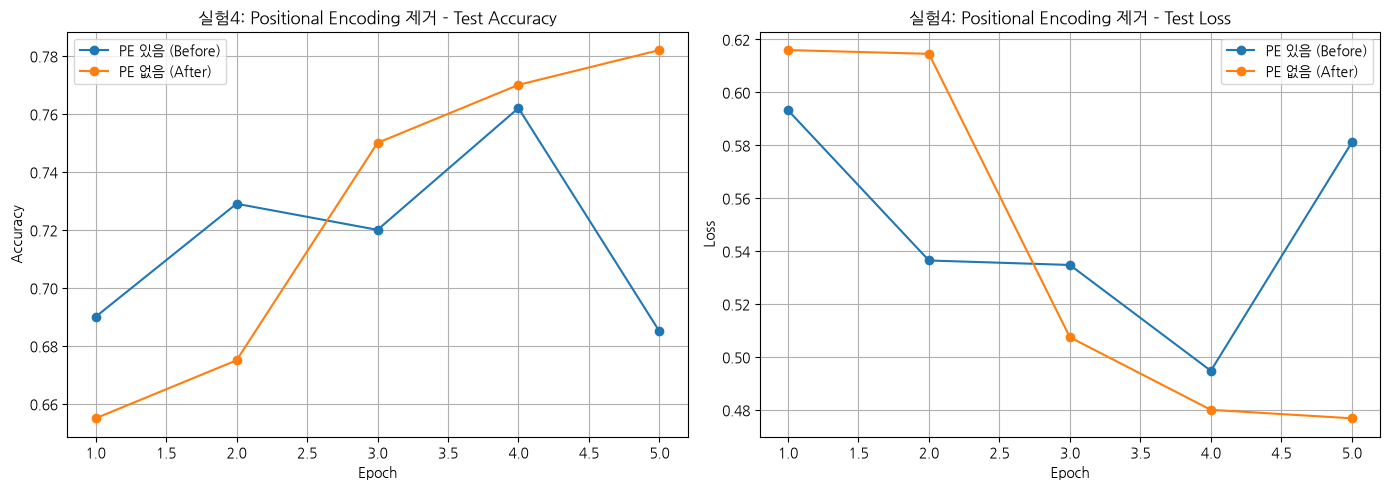


[실험 4 결과 요약]
설정                     Test Accuracy
-------------------------------------
PE 있음 (Before)                0.6850
PE 없음 (After)                 0.7820
성능 변화                        -0.0970


In [14]:
cfg_pe_on  = {**CONFIG, "use_pe": True,  "use_residual": True}
cfg_pe_off = {**CONFIG, "use_pe": False, "use_residual": True}

_, res_pe_on,  acc_pe_on  = run_experiment(cfg_pe_on,  train_loader, test_loader, "실험4 - PE 있음 (Before)")
_, res_pe_off, acc_pe_off = run_experiment(cfg_pe_off, train_loader, test_loader, "실험4 - PE 없음 (After)")

plot_results(
    {"PE 있음 (Before)": res_pe_on, "PE 없음 (After)": res_pe_off},
    title="실험4: Positional Encoding 제거"
)

print("\n[실험 4 결과 요약]")
print(f"{'설정':<20} {'Test Accuracy':>15}")
print("-" * 37)
print(f"{'PE 있음 (Before)':<20} {acc_pe_on:>15.4f}")
print(f"{'PE 없음 (After)':<20} {acc_pe_off:>15.4f}")
print(f"{'성능 변화':<20} {acc_pe_on - acc_pe_off:>+15.4f}")

## 13. 실험 6 — Residual Connection 제거 실험
`use_residual=False`로 Residual을 제거한 모델과 비교

**분석 포인트**: Residual Connection이 없으면 무슨 문제가 생길까?
- **Vanishing Gradient**: 깊은 네트워크에서 기울기가 사라짐
- **학습 불안정**: 각 레이어가 처음부터 모든 정보를 새로 학습해야 함


[실험] 실험6 - Residual 있음 (Before)
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=True


  Epoch 1/5 | Train Loss: 0.6944 Acc: 0.5542 | Test  Loss: 0.5959 Acc: 0.6910
  Epoch 2/5 | Train Loss: 0.5932 Acc: 0.6752 | Test  Loss: 0.6113 Acc: 0.6710
  Epoch 3/5 | Train Loss: 0.5512 Acc: 0.7170 | Test  Loss: 0.5115 Acc: 0.7440
  Epoch 4/5 | Train Loss: 0.5180 Acc: 0.7402 | Test  Loss: 0.4857 Acc: 0.7530
  Epoch 5/5 | Train Loss: 0.4892 Acc: 0.7584 | Test  Loss: 0.4696 Acc: 0.7840
  => 최종 Test Accuracy: 0.7840

[실험] 실험6 - Residual 없음 (After)
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=False
  Epoch 1/5 | Train Loss: 0.7296 Acc: 0.4942 | Test  Loss: 0.6964 Acc: 0.5000
  Epoch 2/5 | Train Loss: 0.6976 Acc: 0.5070 | Test  Loss: 0.7138 Acc: 0.5000
  Epoch 3/5 | Train Loss: 0.6564 Acc: 0.6044 | Test  Loss: 0.6014 Acc: 0.6720
  Epoch 4/5 | Train Loss: 0.5665 Acc: 0.7152 | Test  Loss: 0.5272 Acc: 0.7410
  Epoch 5/5 | Train Loss: 0.5215 Acc: 0.7480 | Test  Loss: 0.5440 Acc: 0.7300
  => 최종 Test Accuracy: 0.7300


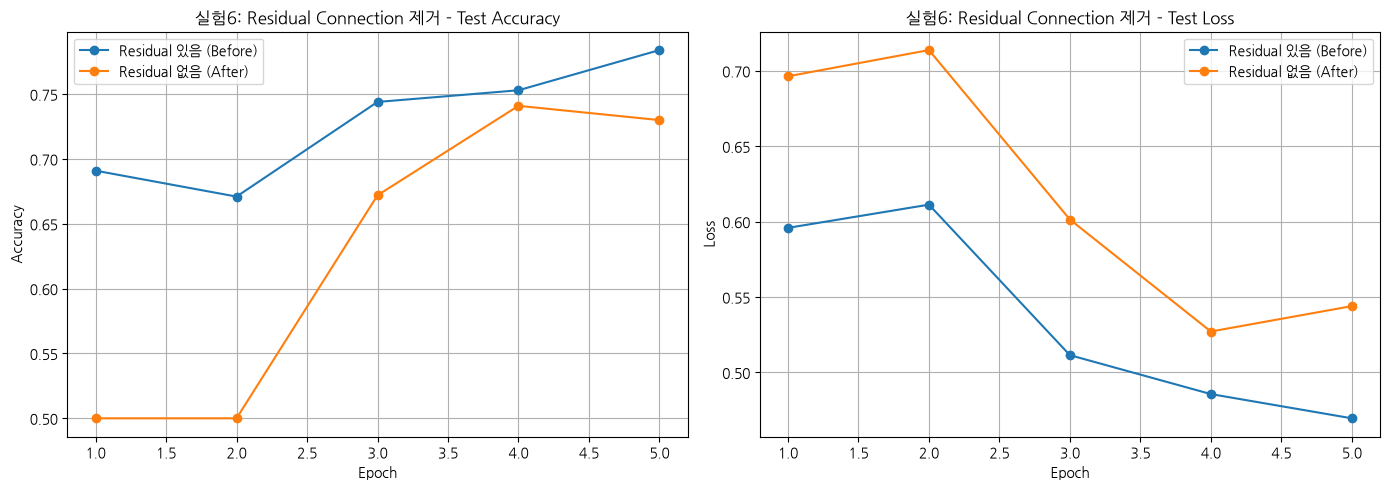


[실험 6 결과 요약]
설정                          Test Accuracy
------------------------------------------
Residual 있음 (Before)               0.7840
Residual 없음 (After)                0.7300
성능 변화                             +0.0540


In [15]:
cfg_res_on  = {**CONFIG, "use_pe": True, "use_residual": True}
cfg_res_off = {**CONFIG, "use_pe": True, "use_residual": False}

_, res_res_on,  acc_res_on  = run_experiment(cfg_res_on,  train_loader, test_loader, "실험6 - Residual 있음 (Before)")
_, res_res_off, acc_res_off = run_experiment(cfg_res_off, train_loader, test_loader, "실험6 - Residual 없음 (After)")

plot_results(
    {"Residual 있음 (Before)": res_res_on, "Residual 없음 (After)": res_res_off},
    title="실험6: Residual Connection 제거"
)

print("\n[실험 6 결과 요약]")
print(f"{'설정':<25} {'Test Accuracy':>15}")
print("-" * 42)
print(f"{'Residual 있음 (Before)':<25} {acc_res_on:>15.4f}")
print(f"{'Residual 없음 (After)':<25} {acc_res_off:>15.4f}")
print(f"{'성능 변화':<25} {acc_res_on - acc_res_off:>+15.4f}")

## 14. 실험 8 — FFN 크기 변경
`d_ff`를 128, 256, 512, 1024로 변경하며 성능 변화를 측정

**분석 포인트**: FFN이 클수록 좋은가? Transformer에서 FFN의 역할은?
- FFN은 각 토큰의 표현을 비선형 변환으로 풍부하게 만드는 역할
- 너무 크면 과적합, 너무 작으면 표현력 부족


[실험] 실험8 - FFN 크기: 128
  n_layer=2, n_head=4, d_ff=128, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6728 Acc: 0.5792 | Test  Loss: 0.6270 Acc: 0.6470
  Epoch 2/5 | Train Loss: 0.6005 Acc: 0.6662 | Test  Loss: 0.5402 Acc: 0.7150
  Epoch 3/5 | Train Loss: 0.5462 Acc: 0.7122 | Test  Loss: 0.4738 Acc: 0.7660
  Epoch 4/5 | Train Loss: 0.4743 Acc: 0.7732 | Test  Loss: 0.4556 Acc: 0.7910
  Epoch 5/5 | Train Loss: 0.4473 Acc: 0.7964 | Test  Loss: 0.4668 Acc: 0.7920
  => 최종 Test Accuracy: 0.7920

[실험] 실험8 - FFN 크기: 256
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6886 Acc: 0.5650 | Test  Loss: 0.6226 Acc: 0.6680
  Epoch 2/5 | Train Loss: 0.6143 Acc: 0.6568 | Test  Loss: 0.5565 Acc: 0.7180
  Epoch 3/5 | Train Loss: 0.5703 Acc: 0.7070 | Test  Loss: 0.5464 Acc: 0.7230
  Epoch 4/5 | Train Loss: 0.5315 Acc: 0.7382 | Test  Loss: 0.5208 Acc: 0.7370
  Epoch 5/5 | Train Loss: 0.5096 Acc: 0.7548 | Test  Loss: 0.6111 Acc: 0.6780
  => 최종 Test A

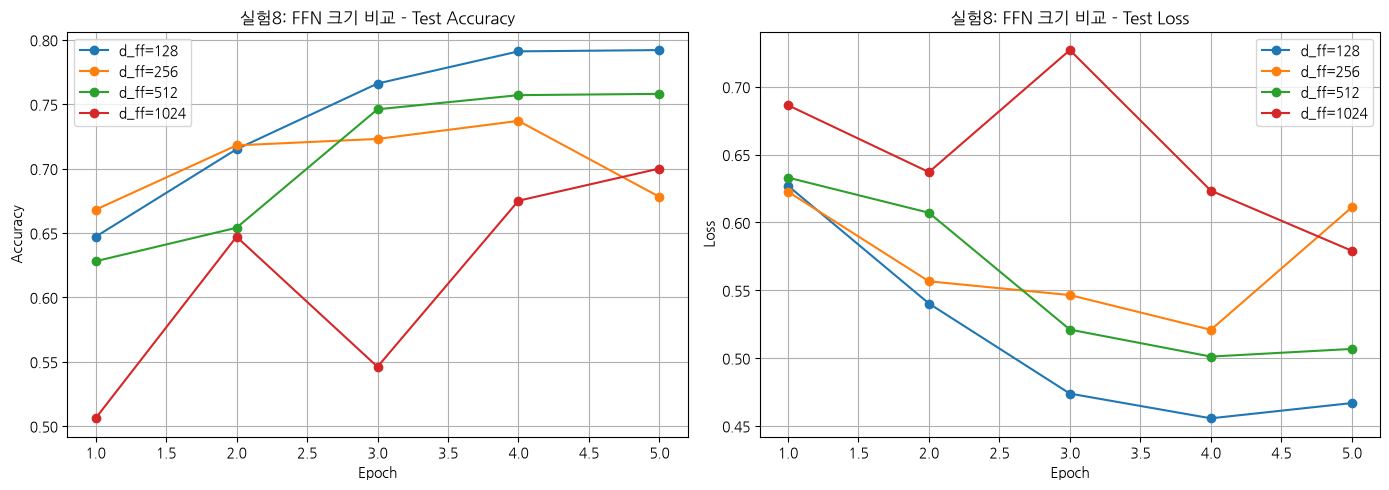


[실험 8 결과 요약]
설정             Test Accuracy
-----------------------------
d_ff=128              0.7920
d_ff=256              0.6780
d_ff=512              0.7580
d_ff=1024             0.7000



In [16]:
results_exp8 = {}
acc_exp8     = {}

for d_ff in [128, 256, 512, 1024]:
    cfg = {**CONFIG, "d_ff": d_ff, "use_pe": True, "use_residual": True}
    _, res, acc = run_experiment(
        cfg, train_loader, test_loader, f"실험8 - FFN 크기: {d_ff}"
    )
    results_exp8[f"d_ff={d_ff}"] = res
    acc_exp8[f"d_ff={d_ff}"]     = acc

plot_results(results_exp8, title="실험8: FFN 크기 비교")

print("\n[실험 8 결과 요약]")
print(f"{'설정':<12} {'Test Accuracy':>15}")
print("-" * 29)
for k, v in acc_exp8.items():
    print(f"{k:<12} {v:>15.4f}")
print()

## 15. Single Head Transformer
Multi-Head vs Single Head 성능 비교 + **Attention Map 시각화 (미션)**

**분석 포인트**: Multi-head가 정말 필요한가?
- 각 head가 서로 다른 관계를 학습할 수 있음
- Single head는 하나의 관점만 포착


[실험] Single Head 실험 - Multi Head (n_head=4)
  n_layer=2, n_head=4, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6994 Acc: 0.5524 | Test  Loss: 0.5810 Acc: 0.7030
  Epoch 2/5 | Train Loss: 0.5972 Acc: 0.6684 | Test  Loss: 0.5233 Acc: 0.7260
  Epoch 3/5 | Train Loss: 0.5381 Acc: 0.7272 | Test  Loss: 0.5223 Acc: 0.7230
  Epoch 4/5 | Train Loss: 0.4956 Acc: 0.7510 | Test  Loss: 0.5499 Acc: 0.7310
  Epoch 5/5 | Train Loss: 0.4580 Acc: 0.7850 | Test  Loss: 0.4765 Acc: 0.7710
  => 최종 Test Accuracy: 0.7710

[실험] Single Head 실험 - Single Head (n_head=1)
  n_layer=2, n_head=1, d_ff=256, use_pe=True, use_residual=True
  Epoch 1/5 | Train Loss: 0.6928 Acc: 0.5482 | Test  Loss: 0.6820 Acc: 0.6180
  Epoch 2/5 | Train Loss: 0.6624 Acc: 0.6060 | Test  Loss: 0.6388 Acc: 0.6300
  Epoch 3/5 | Train Loss: 0.6341 Acc: 0.6492 | Test  Loss: 0.6276 Acc: 0.6410
  Epoch 4/5 | Train Loss: 0.6101 Acc: 0.6702 | Test  Loss: 0.5812 Acc: 0.6890
  Epoch 5/5 | Train Loss: 0.5740 Acc: 0.7042 | Te

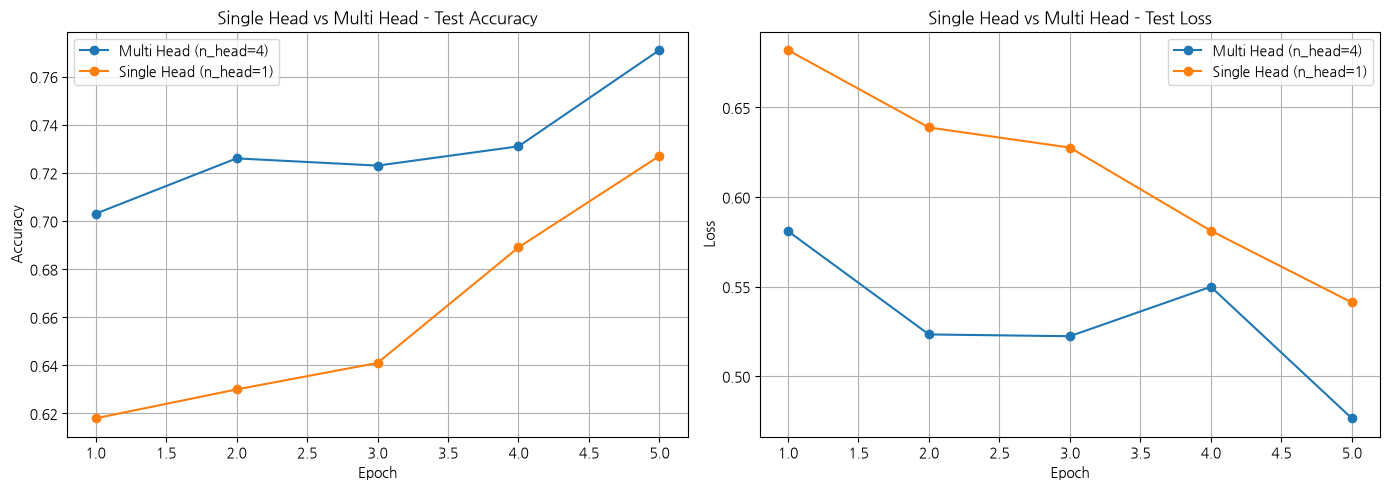


[Single Head 결과 요약]
설정                          Test Accuracy
------------------------------------------
Multi Head (n_head=4)              0.7710
Single Head (n_head=1)             0.7270
성능 변화                             +0.0440


In [17]:
cfg_multi  = {**CONFIG, "n_head": 4, "use_pe": True, "use_residual": True,
              "single_head_mode": False}
cfg_single = {**CONFIG, "n_head": 1, "use_pe": True, "use_residual": True,
              "single_head_mode": True}

model_multi,  res_multi,  acc_multi  = run_experiment(
    cfg_multi,  train_loader, test_loader, "Single Head 실험 - Multi Head (n_head=4)"
)
model_single, res_single, acc_single = run_experiment(
    cfg_single, train_loader, test_loader, "Single Head 실험 - Single Head (n_head=1)"
)

plot_results(
    {"Multi Head (n_head=4)": res_multi, "Single Head (n_head=1)": res_single},
    title="Single Head vs Multi Head"
)

print("\n[Single Head 결과 요약]")
print(f"{'설정':<25} {'Test Accuracy':>15}")
print("-" * 42)
print(f"{'Multi Head (n_head=4)':<25} {acc_multi:>15.4f}")
print(f"{'Single Head (n_head=1)':<25} {acc_single:>15.4f}")
print(f"{'성능 변화':<25} {acc_multi - acc_single:>+15.4f}")

## 16. (미션) Attention Map 시각화
Single Head 모델의 Attention weight를 heatmap으로 출력

- 행(Query): 각 단어가 **어디를 보는가**
- 열(Key): **어디로부터 정보를 가져오는가**
- 밝을수록 높은 Attention 가중치

=== Single Head Attention Map ===


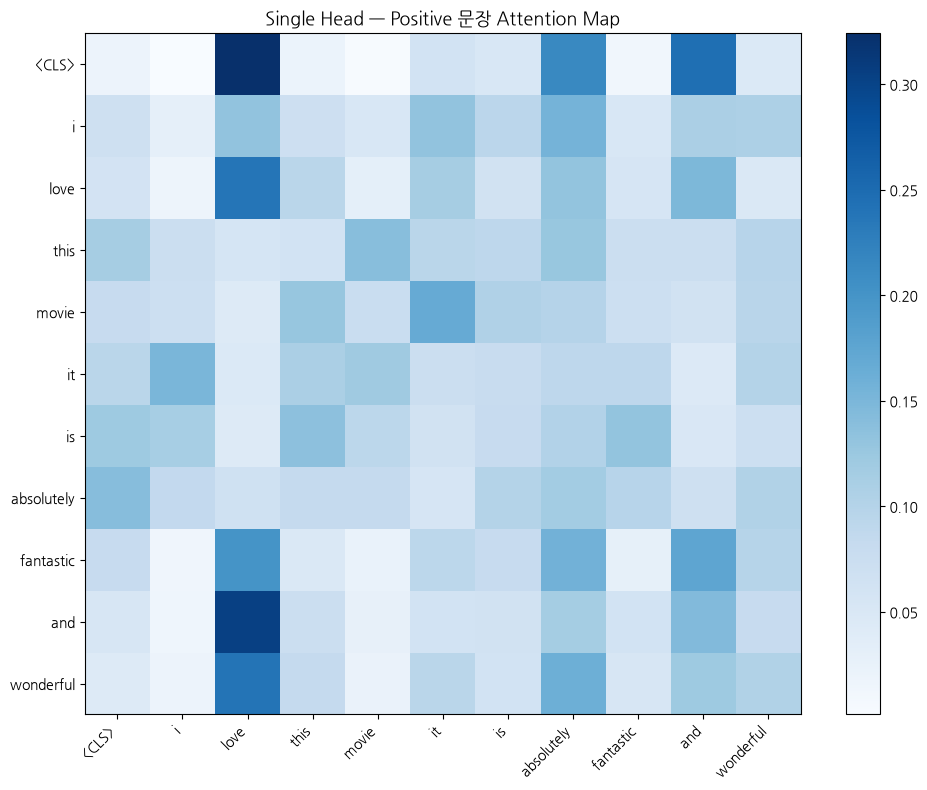

Attention Map 출력 완료: Single Head — Positive 문장 Attention Map


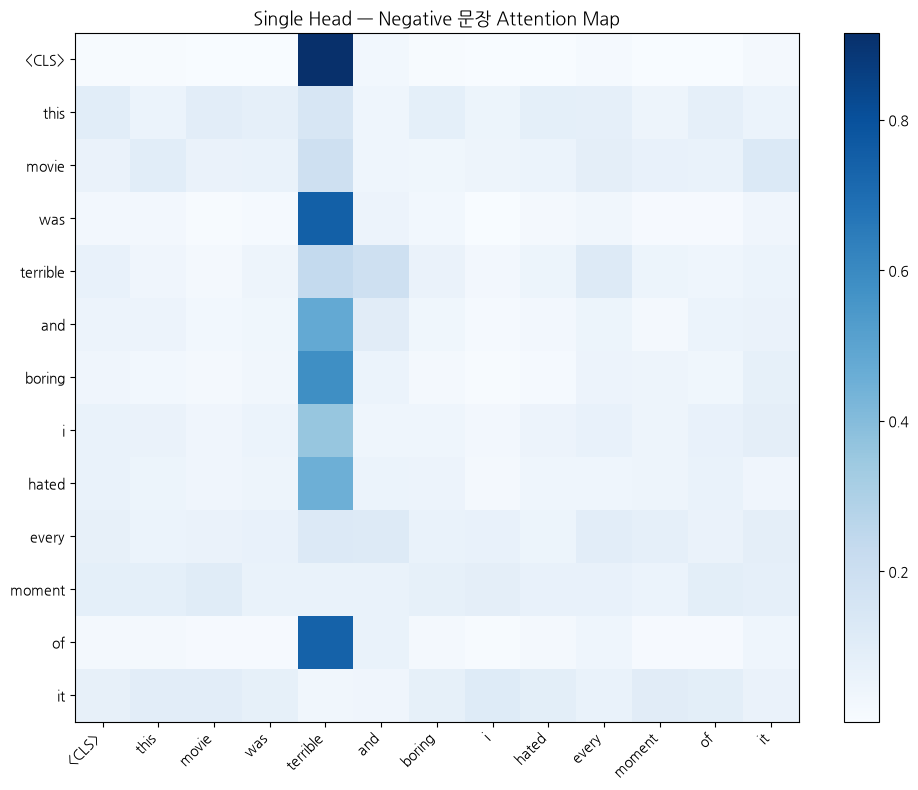

Attention Map 출력 완료: Single Head — Negative 문장 Attention Map

=== Multi Head Attention Map (Head 0) ===


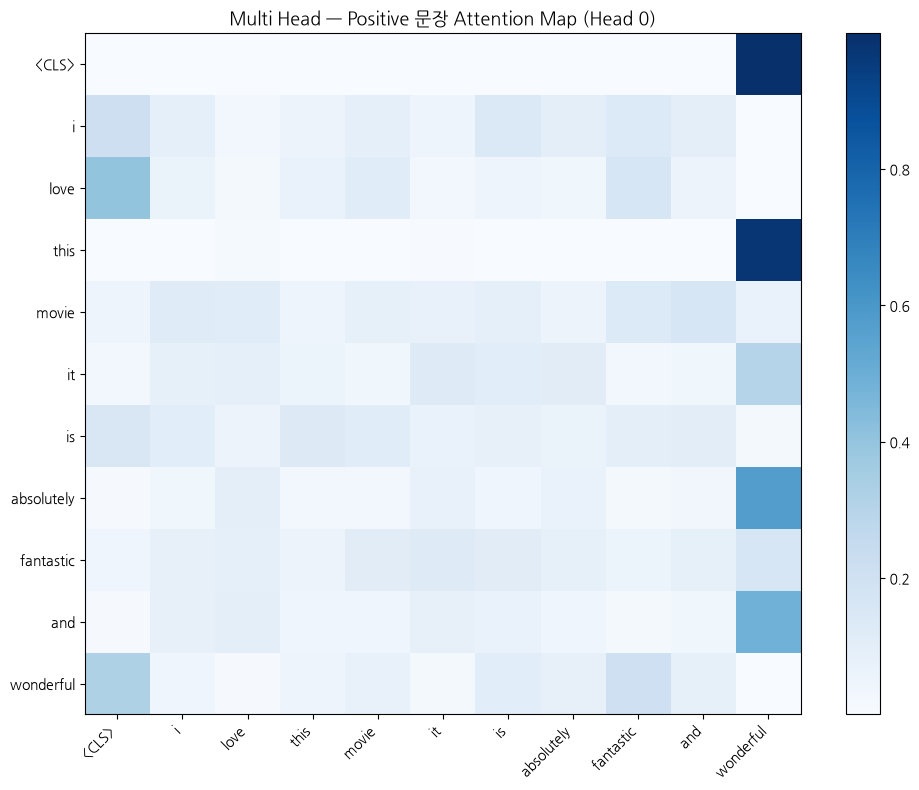

Attention Map 출력 완료: Multi Head — Positive 문장 Attention Map (Head 0)


In [18]:
@torch.no_grad()
def visualize_attention_map(model, tokenizer, text, max_len=64,
                             title="Attention Map", save_path=None):
    """단일 문장에 대한 Attention Map 시각화"""
    model.eval()
    ids = torch.tensor([tokenizer.encode(text, max_len)]).to(device)
    _, attn_weights = model(ids)

    # 마지막 Encoder layer의 attention 가져오기
    attn = attn_weights[-1][0]  # (n_head, seq_len, seq_len) or (seq_len, seq_len)
    if attn.dim() == 3:
        attn = attn[0]          # 첫 번째 head
    attn = attn.cpu().numpy()

    tokens   = ["<CLS>"] + text.lower().split()
    tokens   = tokens[:max_len]
    show_len = min(15, len(tokens))   # 앞 15개 토큰만 표시

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(attn[:show_len, :show_len], cmap="Blues", aspect="auto")
    ax.set_xticks(range(show_len))
    ax.set_yticks(range(show_len))
    ax.set_xticklabels(tokens[:show_len], rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(tokens[:show_len], fontsize=10)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()
    print(f"Attention Map 출력 완료: {title}")


# 시각화할 샘플 문장
sample_positive = "I love this movie it is absolutely fantastic and wonderful"
sample_negative = "This movie was terrible and boring I hated every moment of it"

print("=== Single Head Attention Map ===")
visualize_attention_map(
    model_single, tokenizer, sample_positive,
    max_len=CONFIG["max_len"],
    title="Single Head — Positive 문장 Attention Map"
)
visualize_attention_map(
    model_single, tokenizer, sample_negative,
    max_len=CONFIG["max_len"],
    title="Single Head — Negative 문장 Attention Map"
)

print("\n=== Multi Head Attention Map (Head 0) ===")
visualize_attention_map(
    model_multi, tokenizer, sample_positive,
    max_len=CONFIG["max_len"],
    title="Multi Head — Positive 문장 Attention Map (Head 0)"
)

### Multi-Head: 모든 Head의 Attention Map 비교

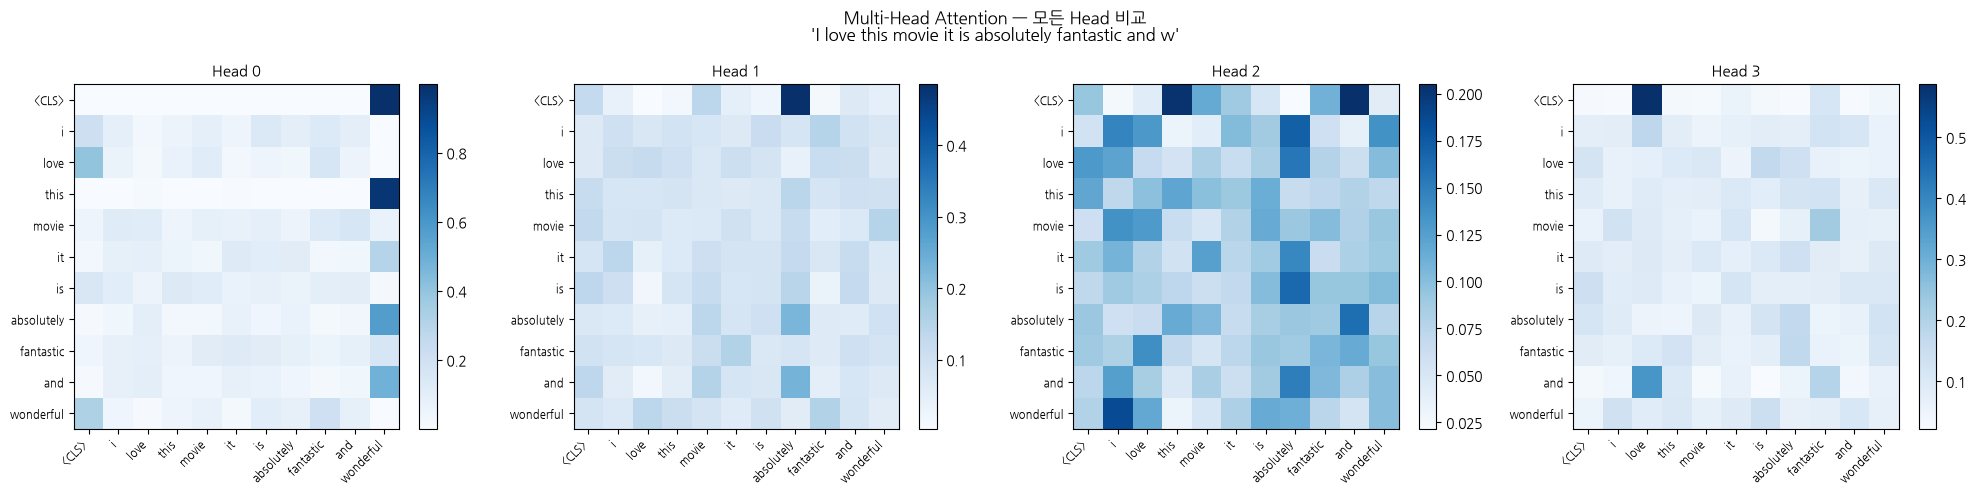

In [19]:
@torch.no_grad()
def visualize_all_heads(model, tokenizer, text, max_len=64, n_head=4):
    """Multi-Head 모델의 모든 head Attention Map 비교"""
    model.eval()
    ids = torch.tensor([tokenizer.encode(text, max_len)]).to(device)
    _, attn_weights = model(ids)

    attn = attn_weights[-1][0].cpu().numpy()  # (n_head, seq_len, seq_len)
    tokens   = ["<CLS>"] + text.lower().split()
    show_len = min(12, len(tokens))

    fig, axes = plt.subplots(1, n_head, figsize=(5 * n_head, 5))
    if n_head == 1:
        axes = [axes]

    for h in range(n_head):
        a = attn[h] if attn.ndim == 3 else attn
        im = axes[h].imshow(a[:show_len, :show_len], cmap="Blues", aspect="auto")
        axes[h].set_title(f"Head {h}", fontsize=11)
        axes[h].set_xticks(range(show_len))
        axes[h].set_yticks(range(show_len))
        axes[h].set_xticklabels(tokens[:show_len], rotation=45, ha="right", fontsize=8)
        axes[h].set_yticklabels(tokens[:show_len], fontsize=8)
        plt.colorbar(im, ax=axes[h])

    plt.suptitle(f"Multi-Head Attention — 모든 Head 비교\n'{text[:50]}'", fontsize=12)
    plt.tight_layout()
    plt.show()


visualize_all_heads(model_multi, tokenizer, sample_positive, n_head=CONFIG["n_head"])

## 17. 전체 실험 결과 요약

전체 실험 결과 요약
실험                                         Test Acc
----------------------------------------------------
실험1 - 베이스라인 (n_layer=2)                      0.7670
실험2 - n_layer=1                              0.6150
실험2 - n_layer=2                              0.7540
실험2 - n_layer=4                              0.7740
실험2 - n_layer=6                              0.7260
실험4 - PE 있음 (Before)                         0.6850
실험4 - PE 없음 (After)                          0.7820
실험6 - Residual 있음 (Before)                   0.7840
실험6 - Residual 없음 (After)                    0.7300
실험8 - d_ff=128                               0.7920
실험8 - d_ff=256                               0.6780
실험8 - d_ff=512                               0.7580
실험8 - d_ff=1024                              0.7000
Single - Multi Head (n_head=4)               0.7710
Single - Single Head (n_head=1)              0.7270


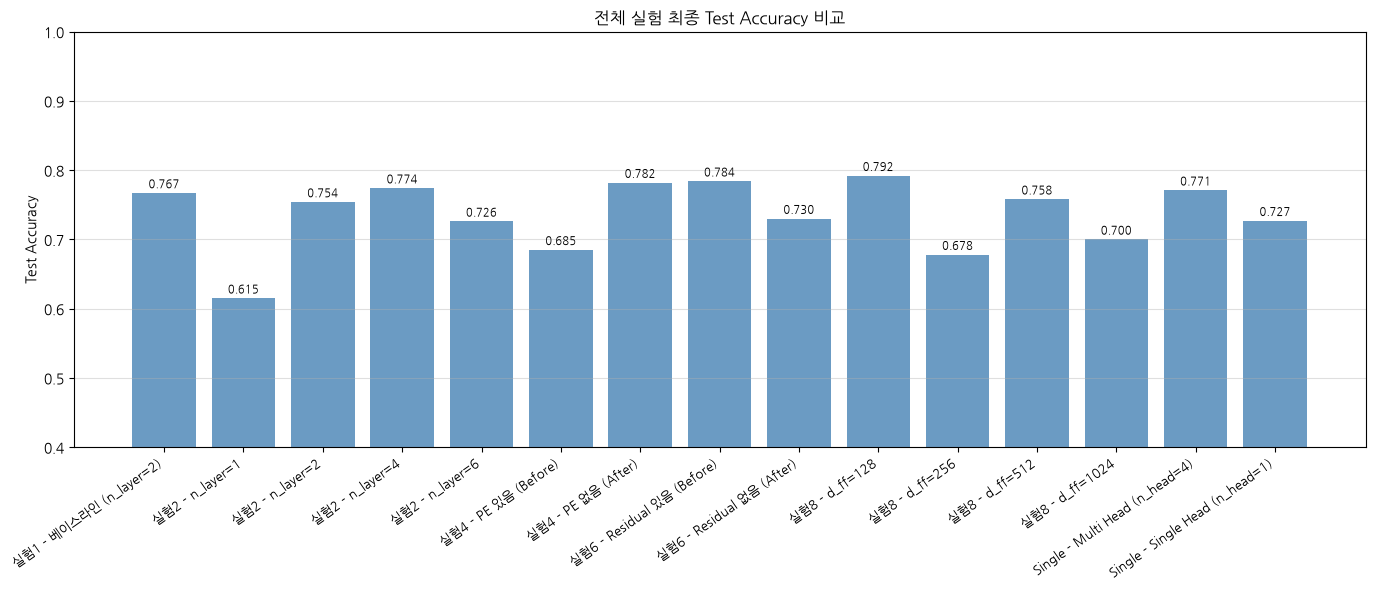

In [20]:
print("=" * 65)
print("전체 실험 결과 요약")
print("=" * 65)

# 실험별 결과 테이블
all_results = {
    "실험1 - 베이스라인 (n_layer=2)": acc_baseline,
    **{f"실험2 - n_layer={k.split('=')[1]}": v for k, v in acc_exp2.items()},
    "실험4 - PE 있음 (Before)":   acc_pe_on,
    "실험4 - PE 없음 (After)":    acc_pe_off,
    "실험6 - Residual 있음 (Before)": acc_res_on,
    "실험6 - Residual 없음 (After)":  acc_res_off,
    **{f"실험8 - d_ff={k.split('=')[1]}": v for k, v in acc_exp8.items()},
    "Single - Multi Head (n_head=4)":  acc_multi,
    "Single - Single Head (n_head=1)": acc_single,
}

print(f"{'실험':<40} {'Test Acc':>10}")
print("-" * 52)
for exp, acc in all_results.items():
    print(f"{exp:<40} {acc:>10.4f}")
print("=" * 65)

# 시각화: 모든 실험 최종 Accuracy 막대그래프
fig, ax = plt.subplots(figsize=(14, 6))
labels = list(all_results.keys())
values = list(all_results.values())
bars = ax.bar(range(len(labels)), values, color="steelblue", alpha=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Test Accuracy")
ax.set_title("전체 실험 최종 Test Accuracy 비교")
ax.set_ylim(0.4, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()